# Reconnaissance d'expressions faciales avec le Deep Learning

## Partie 1 — Recherche, compréhension et préparation des données

L'objectif du projet est de construire progressivement un modèle capable
de reconnaître différentes expressions faciales à partir d'images de visages.

### Dataset choisi : FER-2013

FER-2013 est un dataset de reconnaissance d'expressions faciales créé dans
le cadre du challenge "Challenges in Representation Learning" de l'ICML 2013.

Les images sont des visages en niveaux de gris de taille 48 × 48 pixels.

Les sept classes sont :

- Enervé 
- Degouté
- effrayé 
- Joyeux
- triste
- Surpris
- neutre 

Source originale : ICML 2013 Facial Expression Recognition Challenge.

Pour ce projet, les données sont téléchargées depuis le miroir Kaggle
`msambare/fer2013`.

In [1]:
from pathlib import Path 

import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import pandas as pd 

import tensorflow as tf 
import kagglehub


In [2]:
print("TensorFlow :", tf.__version__)

TensorFlow : 2.21.0


In [3]:
# Détermination de la racine du projet

PROJECT_ROOT = Path.cwd()

# Si le notebook s'exécute depuis /notebooks
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "fer2013"

print("Projet :", PROJECT_ROOT)
print("Dataset :", DATA_DIR)

Projet : c:\Users\User\facial-expression-recognition
Dataset : c:\Users\User\facial-expression-recognition\data\fer2013


In [4]:
if not DATA_DIR.exists():
    print("Téléchargement de FER-2013...")

    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)

    kagglehub.dataset_download(
        "msambare/fer2013",
        output_dir=str(DATA_DIR)
    )

    print("Téléchargement terminé.")
else:
    print("Le dataset est déjà présent.")

Téléchargement de FER-2013...


100%|██████████| 60.3M/60.3M [00:04<00:00, 15.6MB/s]

Extracting files...


Téléchargement terminé.


In [5]:
train_dir = DATA_DIR / "train"
test_dir = DATA_DIR / "test"

print("Train :", train_dir.exists())
print("Test  :", test_dir.exists())

Train : True
Test  : True


In [6]:
classes = sorted([
    directory.name
    for directory in train_dir.iterdir()
    if directory.is_dir()
])

classes

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [7]:
records = []

for split_name, split_dir in {
    "train": train_dir,
    "test": test_dir
}.items():

    for class_dir in sorted(split_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        image_count = len(list(class_dir.glob("*")))

        records.append({
            "split": split_name,
            "class": class_dir.name,
            "images": image_count
        })

class_distribution = pd.DataFrame(records)

class_distribution

,split,class,images
0,train,angry,3995
1,train,disgust,436
2,train,fear,4097
3,train,happy,7215
4,train,neutral,4965
5,train,sad,4830
6,train,surprise,3171
7,test,angry,958
8,test,disgust,111
9,test,fear,1024


In [8]:
sample_image_path = next(train_dir.rglob("*.jpg"))

with Image.open(sample_image_path) as img:
    print("Taille :", img.size)
    print("Mode :", img.mode)
    print("Format :", img.format)

Taille : (48, 48)
Mode : L
Format : JPEG


### Visualisation des différentes expressions

Afin de mieux comprendre le jeu de données, nous affichons plusieurs exemples
pour chacune des sept classes.

Cette visualisation permet également d'observer la variabilité des visages
au sein d'une même expression.

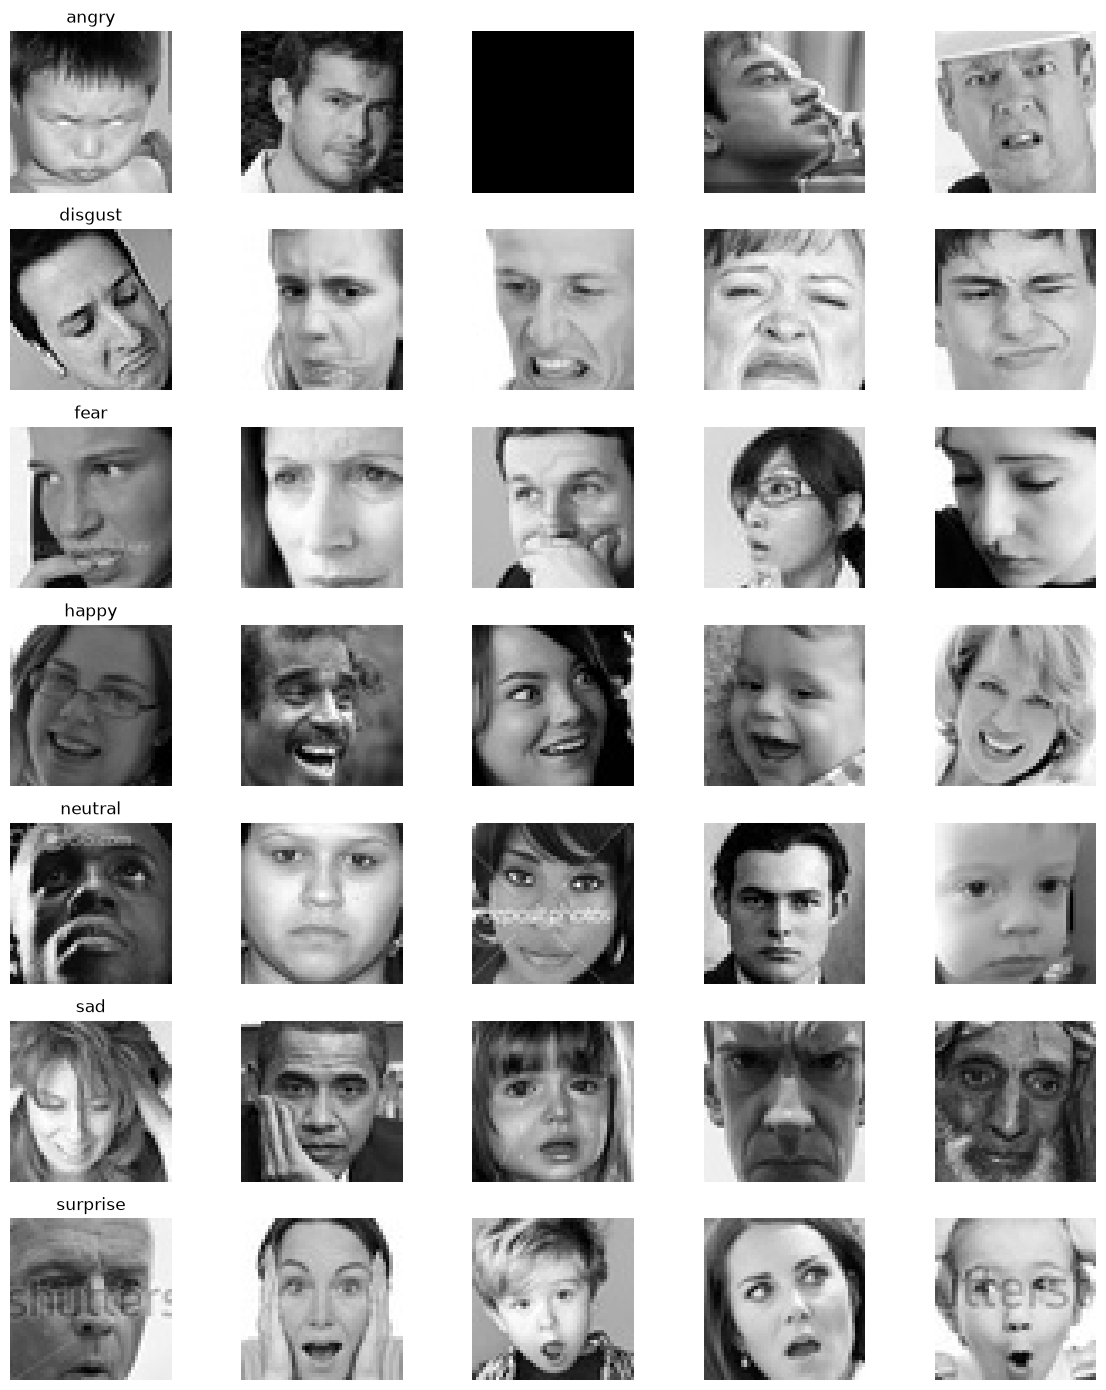

In [9]:
fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=5,
    figsize=(12, 14)
)

for row, class_name in enumerate(classes):

    class_dir = train_dir / class_name
    image_paths = list(class_dir.glob("*.jpg"))[:5]

    for col, image_path in enumerate(image_paths):

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

In [10]:
train_distribution = class_distribution[
    class_distribution["split"] == "train"
].copy()

train_distribution

,split,class,images
0,train,angry,3995
1,train,disgust,436
2,train,fear,4097
3,train,happy,7215
4,train,neutral,4965
5,train,sad,4830
6,train,surprise,3171


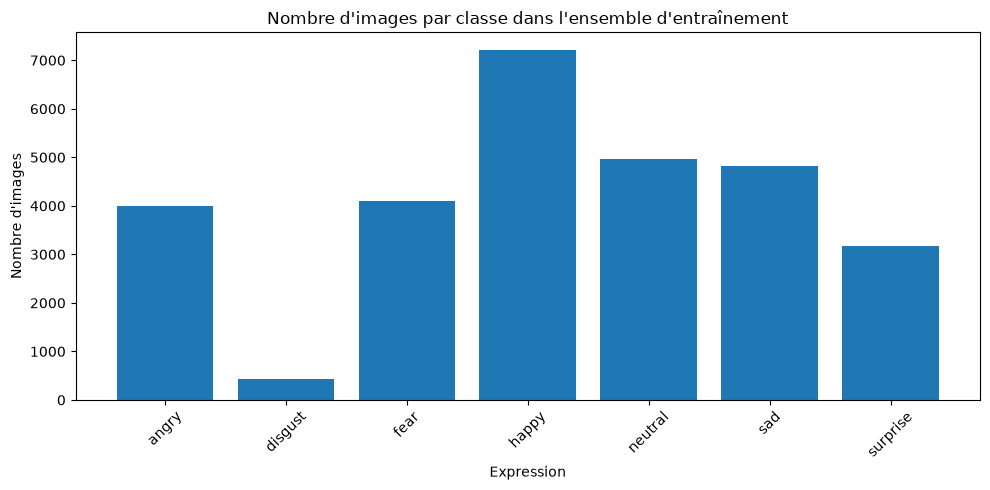

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    train_distribution["class"],
    train_distribution["images"]
)

plt.title("Nombre d'images par classe dans l'ensemble d'entraînement")
plt.xlabel("Expression")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
max_images = train_distribution["images"].max()
min_images = train_distribution["images"].min()

imbalance_ratio = max_images / min_images

print("Classe la plus représentée :", max_images, "images")
print("Classe la moins représentée :", min_images, "images")
print(f"Ratio de déséquilibre : {imbalance_ratio:.2f}")

Classe la plus représentée : 7215 images
Classe la moins représentée : 436 images
Ratio de déséquilibre : 16.55


### Analyse de la distribution des classes

La distribution des images n'est pas parfaitement équilibrée entre les
différentes expressions.

Certaines classes sont davantage représentées que d'autres, ce qui peut
influencer l'apprentissage du modèle. Une classe contenant peu d'exemples
risque notamment d'être plus difficile à apprendre.

Il sera donc important de ne pas évaluer le modèle uniquement avec
l'accuracy globale. Une matrice de confusion et des métriques par classe
seront également étudiées lors de l'évaluation du modèle.

In [13]:
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
SEED = 42

In [14]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


In [15]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [16]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [17]:
class_names = train_dataset.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [18]:
NUM_CLASSES = len(class_names)

print("Nombre de classes :", NUM_CLASSES)

Nombre de classes : 7


In [19]:
for images, labels in train_dataset.take(1):

    print("Shape des images :", images.shape)
    print("Shape des labels :", labels.shape)

    print()
    print("Premiers labels :", labels[:10].numpy())

Shape des images : (64, 48, 48, 1)
Shape des labels : (64,)

Premiers labels : [5 3 3 5 2 3 3 3 5 3]


In [20]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [21]:
train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

test_dataset = test_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

In [22]:
for images, labels in train_dataset.take(1):

    print("Pixel minimum :", images.numpy().min())
    print("Pixel maximum :", images.numpy().max())

Pixel minimum : 0.0
Pixel maximum : 1.0


### Préparation des données

Les images sont chargées par batch de 64 images.

Le dataset d'entraînement original est séparé en deux parties :

- 80 % pour l'entraînement ;
- 20 % pour la validation.

Le dossier de test fourni par FER-2013 est conservé séparément et ne sera
utilisé que pour l'évaluation finale du modèle.

Les images sont en niveaux de gris et possèdent une dimension de
48 × 48 pixels avec un seul canal.

Les valeurs des pixels, initialement comprises entre 0 et 255, sont
normalisées entre 0 et 1 afin de faciliter l'apprentissage du réseau.

Les expressions sont représentées par des labels entiers correspondant aux
différentes classes du dataset.

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Partie 2 — Construction d'un modèle de référence

Avant de construire un réseau convolutif, nous allons entraîner un réseau
de neurones dense simple.

Ce modèle servira de baseline afin de disposer d'un point de comparaison
avec le CNN développé dans la suite du projet.

L'architecture utilisée est :

Image → Flatten → Dense + ReLU → Dense + Softmax

In [24]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [25]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### Architecture du modèle de référence

L'image d'entrée possède une dimension de 48 × 48 pixels avec un seul canal,
soit 2304 valeurs.

La couche `Flatten` transforme l'image en un vecteur de 2304 valeurs sans
ajouter de paramètre entraînable.

La première couche Dense contient 128 neurones avec une activation ReLU.
Elle possède :

2304 × 128 + 128 = 295 040 paramètres.

La couche de sortie contient 7 neurones, correspondant aux 7 expressions
faciales du dataset. Elle utilise une activation Softmax afin de produire
une distribution de probabilités entre les différentes classes.

Cette architecture servira de modèle de référence avant la construction
d'un CNN.

In [26]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entraînement du modèle de référence

Le modèle de référence est entraîné sur les données d'entraînement et évalué
à chaque époque sur l'ensemble de validation.

Nous utilisons dans un premier temps 10 époques afin d'observer le comportement
du modèle sans chercher à optimiser ses performances.

In [27]:
EPOCHS = 10

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10


c:\Users\User\facial-expression-recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


359/359 ━━━━━━━━━━━━━━━━━━━━ 117s 316ms/step - accuracy: 0.2662 - loss: 1.8050 - val_accuracy: 0.2959 - val_loss: 1.7380
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3094 - loss: 1.7217 - val_accuracy: 0.3222 - val_loss: 1.7084
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.3235 - loss: 1.7020 - val_accuracy: 0.3454 - val_loss: 1.6778
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3368 - loss: 1.6796 - val_accuracy: 0.3412 - val_loss: 1.6848
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.3404 - loss: 1.6733 - val_accuracy: 0.3336 - val_loss: 1.6769
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.3444 - loss: 1.6637 - val_accuracy: 0.3468 - val_loss: 1.6715
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3465 - loss: 1.6571 - val_accuracy: 0.3442 - val_loss: 1.6594
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.3522 - loss: 1.6464 - val_accur

In [28]:
history = baseline_history.history

history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

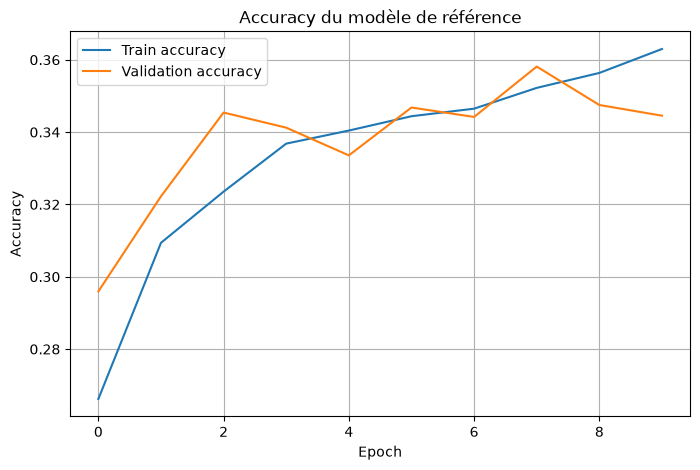

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history["accuracy"], label="Train accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy du modèle de référence")
plt.legend()
plt.grid()

plt.show()

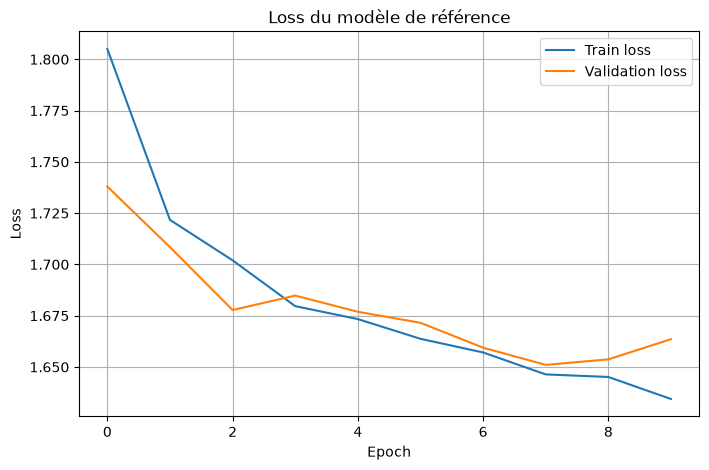

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history["loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss du modèle de référence")
plt.legend()
plt.grid()

plt.show()

In [31]:
val_loss, val_accuracy = baseline_model.evaluate(validation_dataset)

print(f"Validation loss : {val_loss:.4f}")
print(f"Validation accuracy : {val_accuracy:.4f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3445 - loss: 1.6635
Validation loss : 1.6635
Validation accuracy : 0.3445


### Analyse de l'entraînement du modèle de référence

Au cours des premières époques, l'accuracy augmente sur les ensembles
d'entraînement et de validation tandis que la loss diminue. Le modèle
parvient donc bien à apprendre certaines caractéristiques des données.

Les performances restent cependant limitées, avec une accuracy de validation
d'environ 35 %.

À partir des dernières époques, l'accuracy d'entraînement continue de
progresser tandis que l'accuracy de validation stagne puis diminue légèrement.
De même, la loss de validation recommence à augmenter alors que la loss
d'entraînement continue de diminuer.

Ce comportement indique un début de surapprentissage.

Ce résultat constitue notre modèle de référence. Nous chercherons ensuite à
améliorer les performances grâce à un réseau convolutif (CNN), mieux adapté
à l'analyse de la structure spatiale des images.

In [32]:
baseline_val_loss = val_loss
baseline_val_accuracy = val_accuracy

# Partie 3 — Construction d'un CNN avec Keras

Le modèle dense précédent servait de référence mais ne prenait pas directement
en compte la structure spatiale des images.

Nous construisons maintenant un réseau de neurones convolutif (CNN),
plus adapté au traitement d'images.

Le CNN sera composé de plusieurs blocs :

Image
→ Conv2D + ReLU
→ MaxPooling
→ Conv2D + ReLU
→ MaxPooling
→ Conv2D + ReLU
→ MaxPooling
→ Flatten
→ Dense + ReLU
→ Dense + Softmax

In [33]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [34]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Évolution des dimensions dans le CNN

| Couche | Dimensions de sortie | Paramètres |
|---|---:|---:|
| Conv2D - 32 filtres | 48 × 48 × 32 | 320 |
| MaxPooling | 24 × 24 × 32 | 0 |
| Conv2D - 64 filtres | 24 × 24 × 64 | 18 496 |
| MaxPooling | 12 × 12 × 64 | 0 |
| Conv2D - 128 filtres | 12 × 12 × 128 | 73 856 |
| MaxPooling | 6 × 6 × 128 | 0 |
| Flatten | 4608 | 0 |
| Dense | 128 | 589 952 |
| Softmax | 7 | 903 |

Le modèle contient au total 683 527 paramètres entraînables.

# Partie 4 — Entraînement du CNN

Le CNN est entraîné avec l'optimiseur Adam et la fonction de perte
`sparse_categorical_crossentropy`.

Cette fonction de perte est adaptée à notre problème de classification
multiclasse car les labels sont représentés par des entiers allant de 0 à 6.

Le batch size est fixé à 64 images et le modèle est entraîné pendant
10 époques afin de pouvoir comparer ses performances à celles du modèle
de référence.

La métrique principale suivie pendant l'entraînement est l'accuracy.

In [36]:
CNN_EPOCHS = 10

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CNN_EPOCHS
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 110s 287ms/step - accuracy: 0.3209 - loss: 1.7006 - val_accuracy: 0.3785 - val_loss: 1.5761
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 87s 242ms/step - accuracy: 0.4456 - loss: 1.4498 - val_accuracy: 0.4701 - val_loss: 1.4037
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 129s 206ms/step - accuracy: 0.5000 - loss: 1.3113 - val_accuracy: 0.5041 - val_loss: 1.2870
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 74s 206ms/step - accuracy: 0.5460 - loss: 1.2023 - val_accuracy: 0.5198 - val_loss: 1.2602
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 231ms/step - accuracy: 0.5783 - loss: 1.1205 - val_accuracy: 0.5241 - val_loss: 1.2362
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 133s 206ms/step - accuracy: 0.6182 - loss: 1.0323 - val_accuracy: 0.5335 - val_loss: 1.2519
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 73s 202ms/step - accuracy: 0.6489 - loss: 0.9506 - val_accuracy: 0.5300 - val_loss: 1.2838
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 74s 206ms/step - accuracy: 0.6799 - loss

In [37]:
cnn_history_dict = cnn_history.history

cnn_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

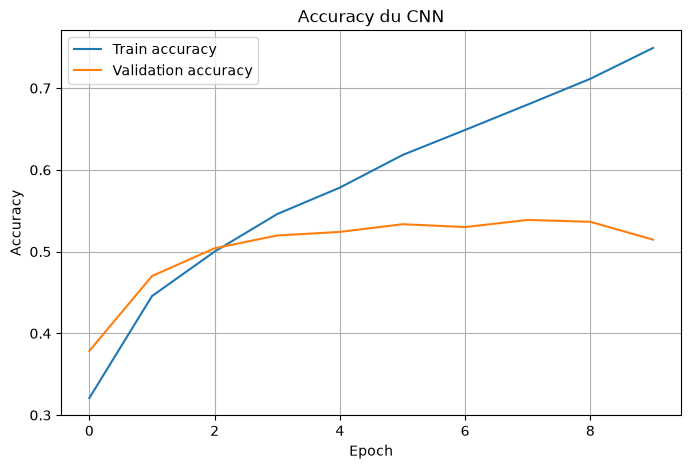

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history_dict["accuracy"],
    label="Train accuracy"
)

plt.plot(
    cnn_history_dict["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy du CNN")
plt.legend()
plt.grid()

plt.show()

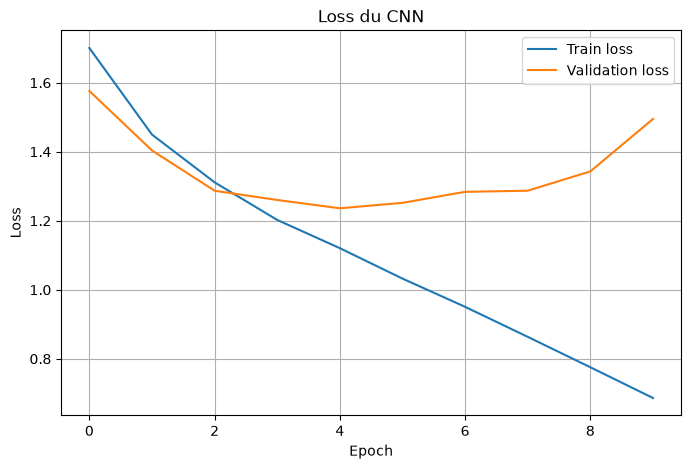

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history_dict["loss"],
    label="Train loss"
)

plt.plot(
    cnn_history_dict["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss du CNN")
plt.legend()
plt.grid()

plt.show()

In [40]:
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(
    validation_dataset
)

print(f"Validation loss     : {cnn_val_loss:.4f}")
print(f"Validation accuracy : {cnn_val_accuracy:.4f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5147 - loss: 1.4950
Validation loss     : 1.4950
Validation accuracy : 0.5147


In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Dense baseline",
        "CNN"
    ],
    "Validation accuracy": [
        baseline_val_accuracy,
        cnn_val_accuracy
    ],
    "Validation loss": [
        baseline_val_loss,
        cnn_val_loss
    ]
})

comparison

,Model,Validation accuracy,Validation loss
0,Dense baseline,0.344539,1.663527
1,CNN,0.514719,1.495001


### Analyse de l'entraînement du CNN

Le CNN apprend rapidement au cours des premières époques.

L'accuracy d'entraînement et l'accuracy de validation augmentent d'abord
de manière similaire. À partir d'environ la troisième ou quatrième époque,
les deux courbes commencent cependant à diverger.

L'accuracy d'entraînement continue d'augmenter jusqu'à environ 75 %,
tandis que l'accuracy de validation se stabilise autour de 53–54 %,
puis diminue légèrement lors des dernières époques.

Cette divergence indique un phénomène de surapprentissage : le modèle
continue de s'adapter aux données d'entraînement sans améliorer sa capacité
de généralisation sur les données de validation.

Malgré ce surapprentissage, le CNN reste nettement plus performant que le
modèle Dense de référence sur l'ensemble de validation.

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [45]:
y_true = []
y_pred = []
y_prob = []
all_images = []

for images, labels in validation_dataset:

    probabilities = cnn_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    confidences = np.max(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(confidences)
    all_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)
all_images = np.array(all_images)

In [47]:
validation_accuracy = np.mean(
    y_true == y_pred
)

print(
    f"Validation accuracy : "
    f"{validation_accuracy:.4f}"
)

Validation accuracy : 0.5147


In [48]:
cm = confusion_matrix(
    y_true,
    y_pred
)

cm

array([[428,   7, 107,  37,  71,  98,  29],
       [ 23,  22,  11,   5,   1,  11,   0],
       [169,   3, 304,  39,  72, 147,  78],
       [116,   3,  79, 911, 115, 125,  53],
       [182,   1,  97,  57, 459, 182,  22],
       [193,   5, 175,  57, 143, 405,  18],
       [ 56,   4, 107,  39,  30,  19, 426]])

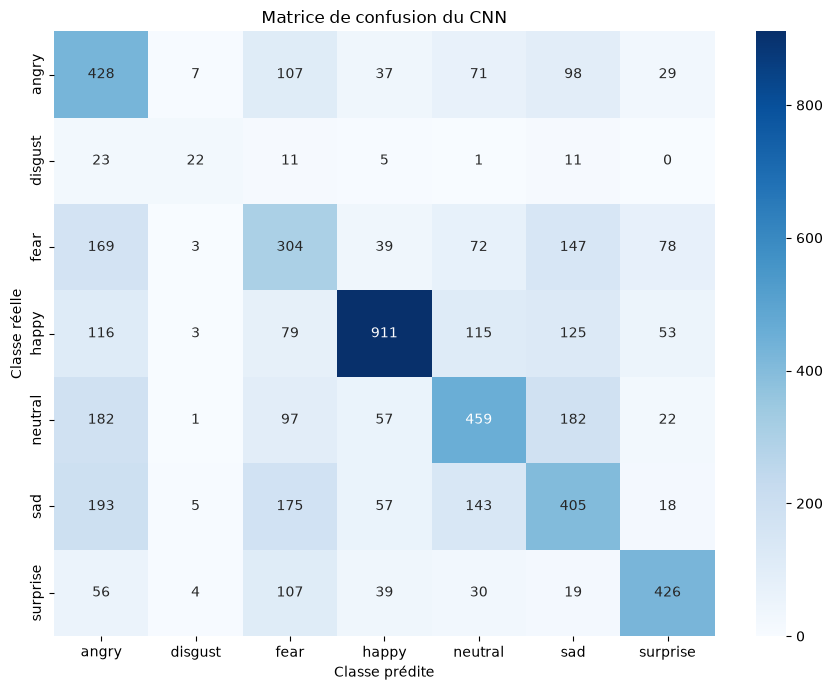

In [49]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion du CNN")

plt.tight_layout()
plt.show()

In [50]:
cm_normalized = cm.astype("float") / cm.sum(
    axis=1,
    keepdims=True
)

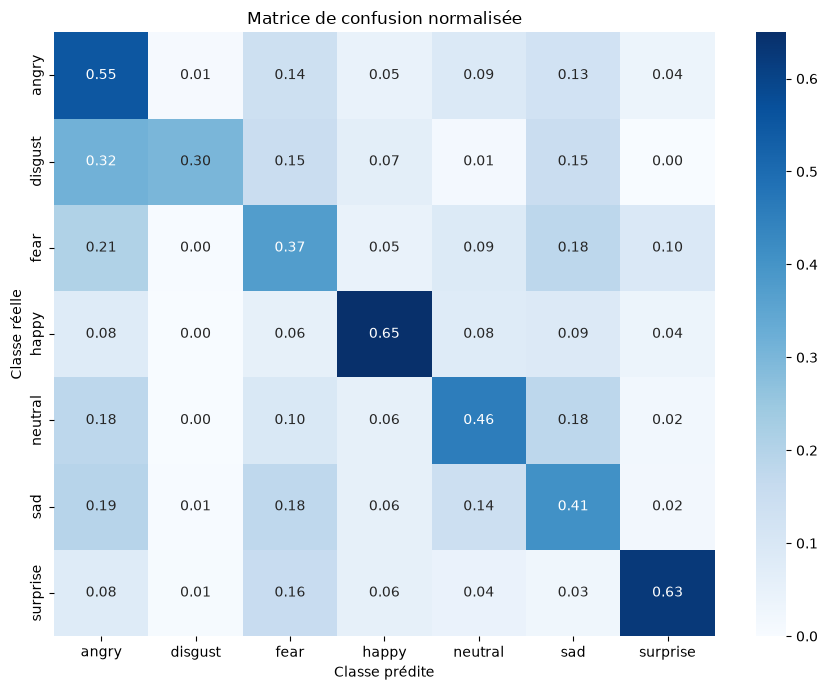

In [51]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion normalisée")

plt.tight_layout()
plt.show()

In [52]:
per_class_accuracy = (
    np.diag(cm)
    / cm.sum(axis=1)
)

class_results = pd.DataFrame({
    "Expression": class_names,
    "Accuracy": per_class_accuracy
})

class_results["Accuracy (%)"] = (
    class_results["Accuracy"] * 100
)

class_results

,Expression,Accuracy,Accuracy (%)
0,angry,0.550837,55.083655
1,disgust,0.301370,30.136986
2,fear,0.374384,37.438424
3,happy,0.649786,64.978602
4,neutral,0.459000,45.900000
5,sad,0.406627,40.662651
6,surprise,0.625551,62.555066


In [53]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry      0.367     0.551     0.440       777
     disgust      0.489     0.301     0.373        73
        fear      0.345     0.374     0.359       812
       happy      0.796     0.650     0.715      1402
     neutral      0.515     0.459     0.485      1000
         sad      0.410     0.407     0.408       996
    surprise      0.681     0.626     0.652       681

    accuracy                          0.515      5741
   macro avg      0.515     0.481     0.491      5741
weighted avg      0.541     0.515     0.523      5741



In [54]:
incorrect_indices = np.where(
    y_true != y_pred
)[0]

len(incorrect_indices)

2786

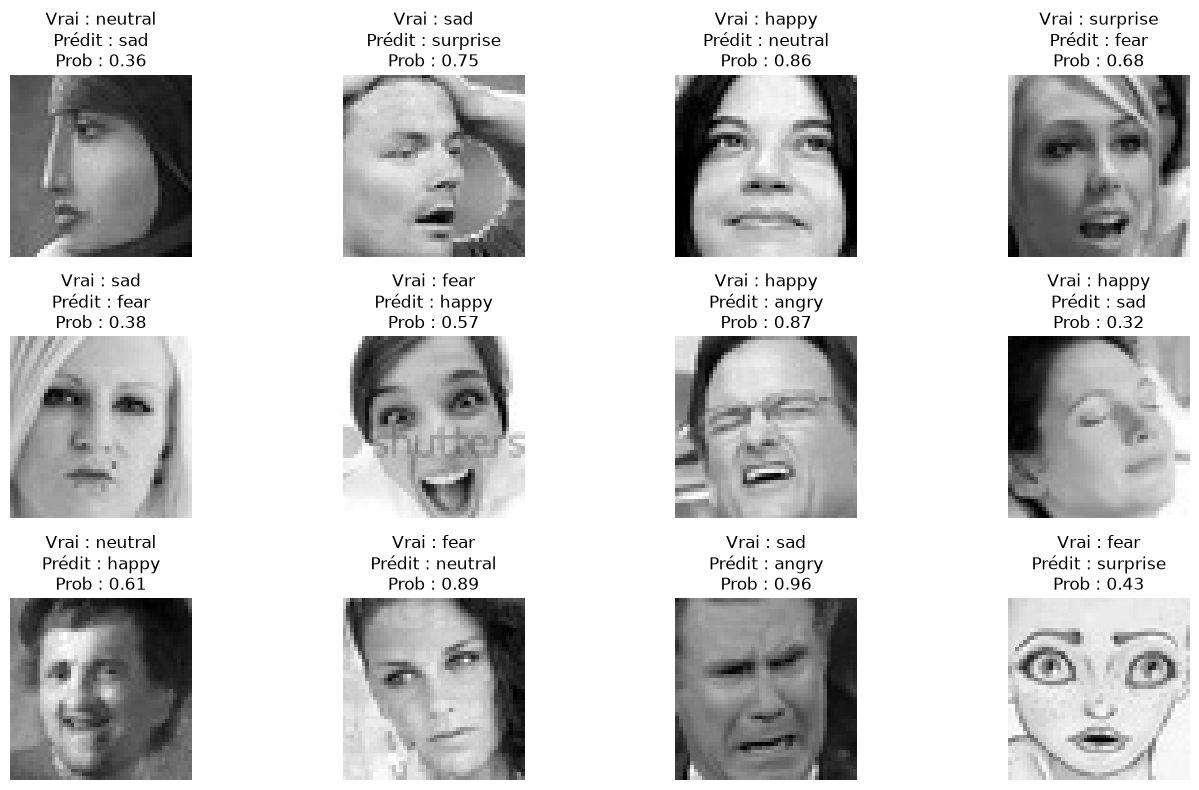

In [55]:
plt.figure(figsize=(14, 8))

for i, index in enumerate(
    incorrect_indices[:12]
):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        all_images[index].squeeze(),
        cmap="gray"
    )

    true_class = class_names[
        y_true[index]
    ]

    predicted_class = class_names[
        y_pred[index]
    ]

    confidence = y_prob[index]

    plt.title(
        f"Vrai : {true_class}\n"
        f"Prédit : {predicted_class}\n"
        f"Prob : {confidence:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

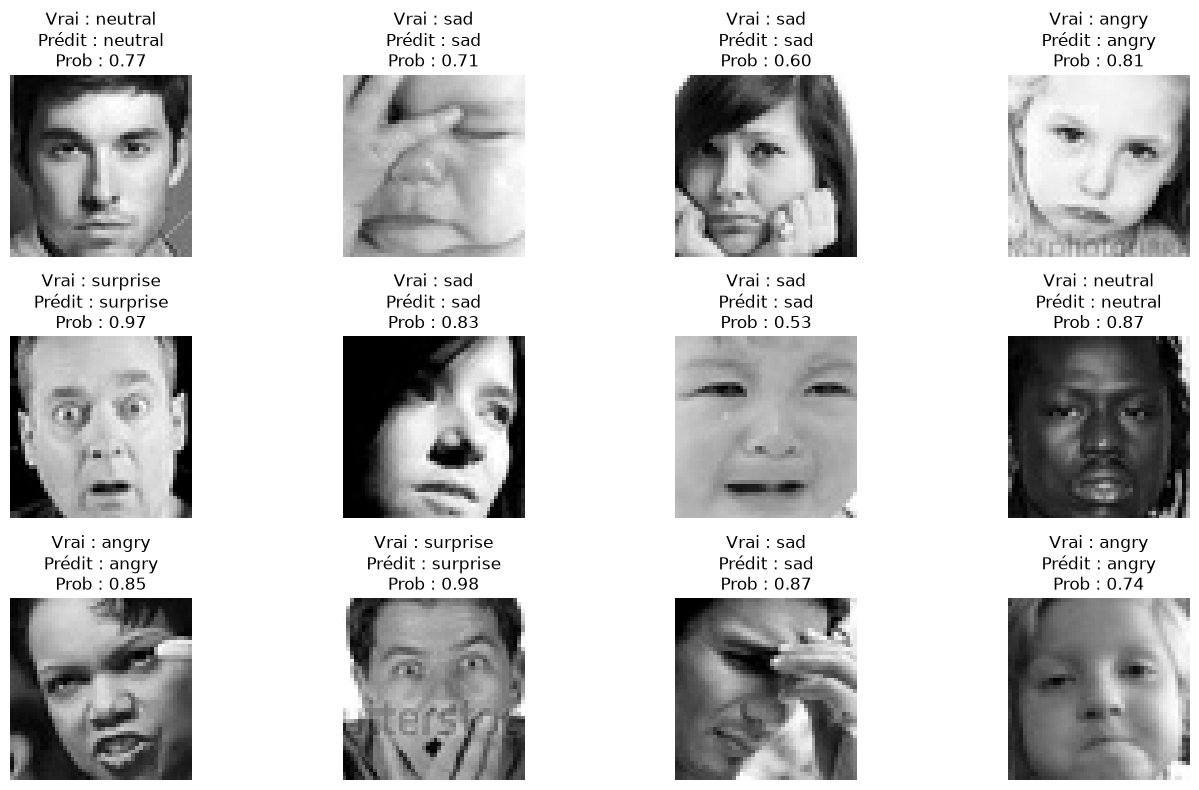

In [56]:
correct_indices = np.where(
    y_true == y_pred
)[0]

plt.figure(figsize=(14, 8))

for i, index in enumerate(
    correct_indices[:12]
):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        all_images[index].squeeze(),
        cmap="gray"
    )

    true_class = class_names[
        y_true[index]
    ]

    predicted_class = class_names[
        y_pred[index]
    ]

    confidence = y_prob[index]

    plt.title(
        f"Vrai : {true_class}\n"
        f"Prédit : {predicted_class}\n"
        f"Prob : {confidence:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Analyse de la matrice de confusion

La matrice de confusion normalisée montre que les performances du CNN
varient fortement selon les expressions.

Les classes les mieux reconnues sont `happy` et `surprise`, avec
respectivement environ 65 % et 63 % de bonnes classifications.
La classe `angry` est également relativement bien reconnue avec environ 55 %.

À l'inverse, les classes `disgust` et `fear` sont plus difficiles à
identifier, avec seulement environ 30 % et 37 % de bonnes classifications.

Plusieurs confusions importantes peuvent être observées :

- environ 32 % des visages `disgust` sont classés comme `angry` ;
- environ 21 % des visages `fear` sont classés comme `angry` ;
- `fear` est également confondu avec `sad` dans environ 18 % des cas ;
- `sad` est fréquemment confondu avec `angry` et `fear` ;
- `neutral` est notamment confondu avec `angry` et `sad`.

Ces résultats montrent que certaines expressions présentant des
caractéristiques visuelles proches sont plus difficiles à distinguer.

L'accuracy globale ne suffit donc pas à évaluer correctement le modèle :
l'analyse par classe met en évidence des performances très différentes
selon les expressions.

### Analyse du classification report

Le classification report confirme que les performances du CNN varient
fortement selon les classes.

La classe `happy` obtient les meilleures performances avec un F1-score
d'environ 0,72, suivie de `surprise` avec environ 0,65.

Les classes `fear` et `disgust` sont plus difficiles à reconnaître,
avec des F1-scores proches de 0,36 et 0,37.

La classe `angry` présente un recall relativement élevé (0,55) mais une
precision plus faible (0,37). Le modèle reconnaît donc une partie importante
des vrais visages en colère, mais a également tendance à prédire `angry`
pour d'autres expressions.

La classe `disgust` est particulièrement peu représentée dans l'ensemble
de validation avec seulement 73 images, contre 1402 pour `happy`.
Ce déséquilibre peut contribuer aux faibles performances observées sur
cette classe.

Le F1-score macro (0,49) est inférieur au F1-score pondéré (0,52).
Cela s'explique par le déséquilibre des classes : la moyenne pondérée donne
davantage d'importance aux classes les plus représentées, notamment `happy`,
qui est également l'une des mieux reconnues.

Ces résultats confirment qu'une simple accuracy globale ne suffit pas pour
évaluer correctement le modèle.